In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('imdb_top_1000.csv')
display(df.info())
display(df.isnull().sum()[df.isnull().sum() > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


None

,0
Certificate,101
Meta_score,157
Gross,169


In [4]:
df.describe()
df.dropna(thresh=5, inplace=True)
# Convert Released_Year to float first to allow NaNs, then fill and convert to int later
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

# Convert Runtime (e.g., "142 min") → numeric
# Check if the column is of string type before applying .str accessor
df['Runtime'] = df['Runtime'].str.replace(" min", "").astype(int)

# Convert Gross (remove commas)
# Check if the column is of string type before applying .str accessor
df['Gross'] = df['Gross'].str.replace(",", "").astype(float)

# Convert Meta_score to float
df['Meta_score'] = pd.to_numeric(df['Meta_score'], errors='coerce')

df.drop_duplicates(inplace=True)
df.shape
# Fill NaN values for 'Released_Year' before converting to int
df.fillna({'Certificate': df['Certificate'].mode().iloc[0],
           'Gross': df['Gross'].mean(),
           'Meta_score': df['Meta_score'].mean(),
            'Released_Year': df['Released_Year'].mean()}, inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   float64
 3   Certificate    1000 non-null   object 
 4   Runtime        1000 non-null   int64  
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     1000 non-null   float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   float64
dtypes: float64(4), int64(2), object(10)
memory usage: 125.1+ KB


In [5]:
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994.0,A,142,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972.0,A,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008.0,UA,152,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974.0,A,202,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957.0,U,96,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0


In [6]:
df.info()
df['Released_Year'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   float64
 3   Certificate    1000 non-null   object 
 4   Runtime        1000 non-null   int64  
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     1000 non-null   float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   float64
dtypes: float64(4), int64(2), object(10)
memory usage: 125.1+ KB


array([1994.        , 1972.        , 2008.        , 1974.        ,
       1957.        , 2003.        , 1993.        , 2010.        ,
       1999.        , 2001.        , 1966.        , 2002.        ,
       1990.        , 1980.        , 1975.        , 2020.        ,
       2019.        , 2014.        , 1998.        , 1997.        ,
       1995.        , 1991.        , 1977.        , 1962.        ,
       1954.        , 1946.        , 2011.        , 2006.        ,
       2000.        , 1988.        , 1985.        , 1968.        ,
       1960.        , 1942.        , 1936.        , 1931.        ,
       2018.        , 2017.        , 2016.        , 2012.        ,
       2009.        , 2007.        , 1984.        , 1981.        ,
       1979.        , 1971.        , 1963.        , 1964.        ,
       1950.        , 1940.        , 2013.        , 2005.        ,
       2004.        , 1992.        , 1987.        , 1986.        ,
       1983.        , 1976.        , 1973.        , 1965.     

#**Rating Trends Over Years:**

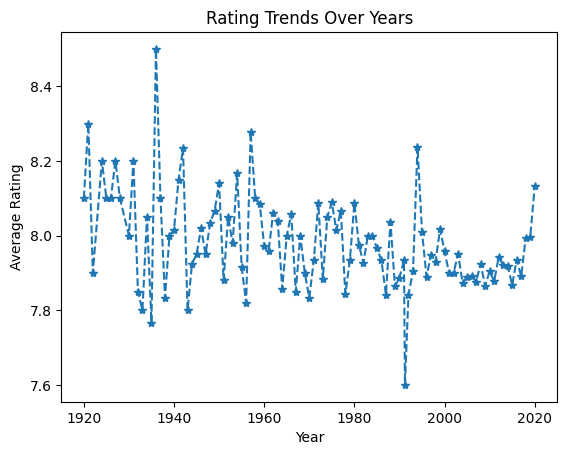

In [7]:
plt.plot(df.groupby('Released_Year')['IMDB_Rating'].mean(), marker='*', linestyle='--')
plt.title('Rating Trends Over Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()

#**Genre Popularity Analysis:**

In [8]:
# genre_counts = df['Genre'].value_counts().reset_index()
# genre_counts.columns = ['Genre', 'Count']

# # Plot
# plt.figure(figsize=(35,15))
# sns.barplot(data=genre_counts, x='Genre', y='Count')
# plt.title('Genre Popularity')
# plt.xlabel('Genre')
# plt.ylabel('Number of Movies')
# plt.xticks(rotation=90)
# plt.show()

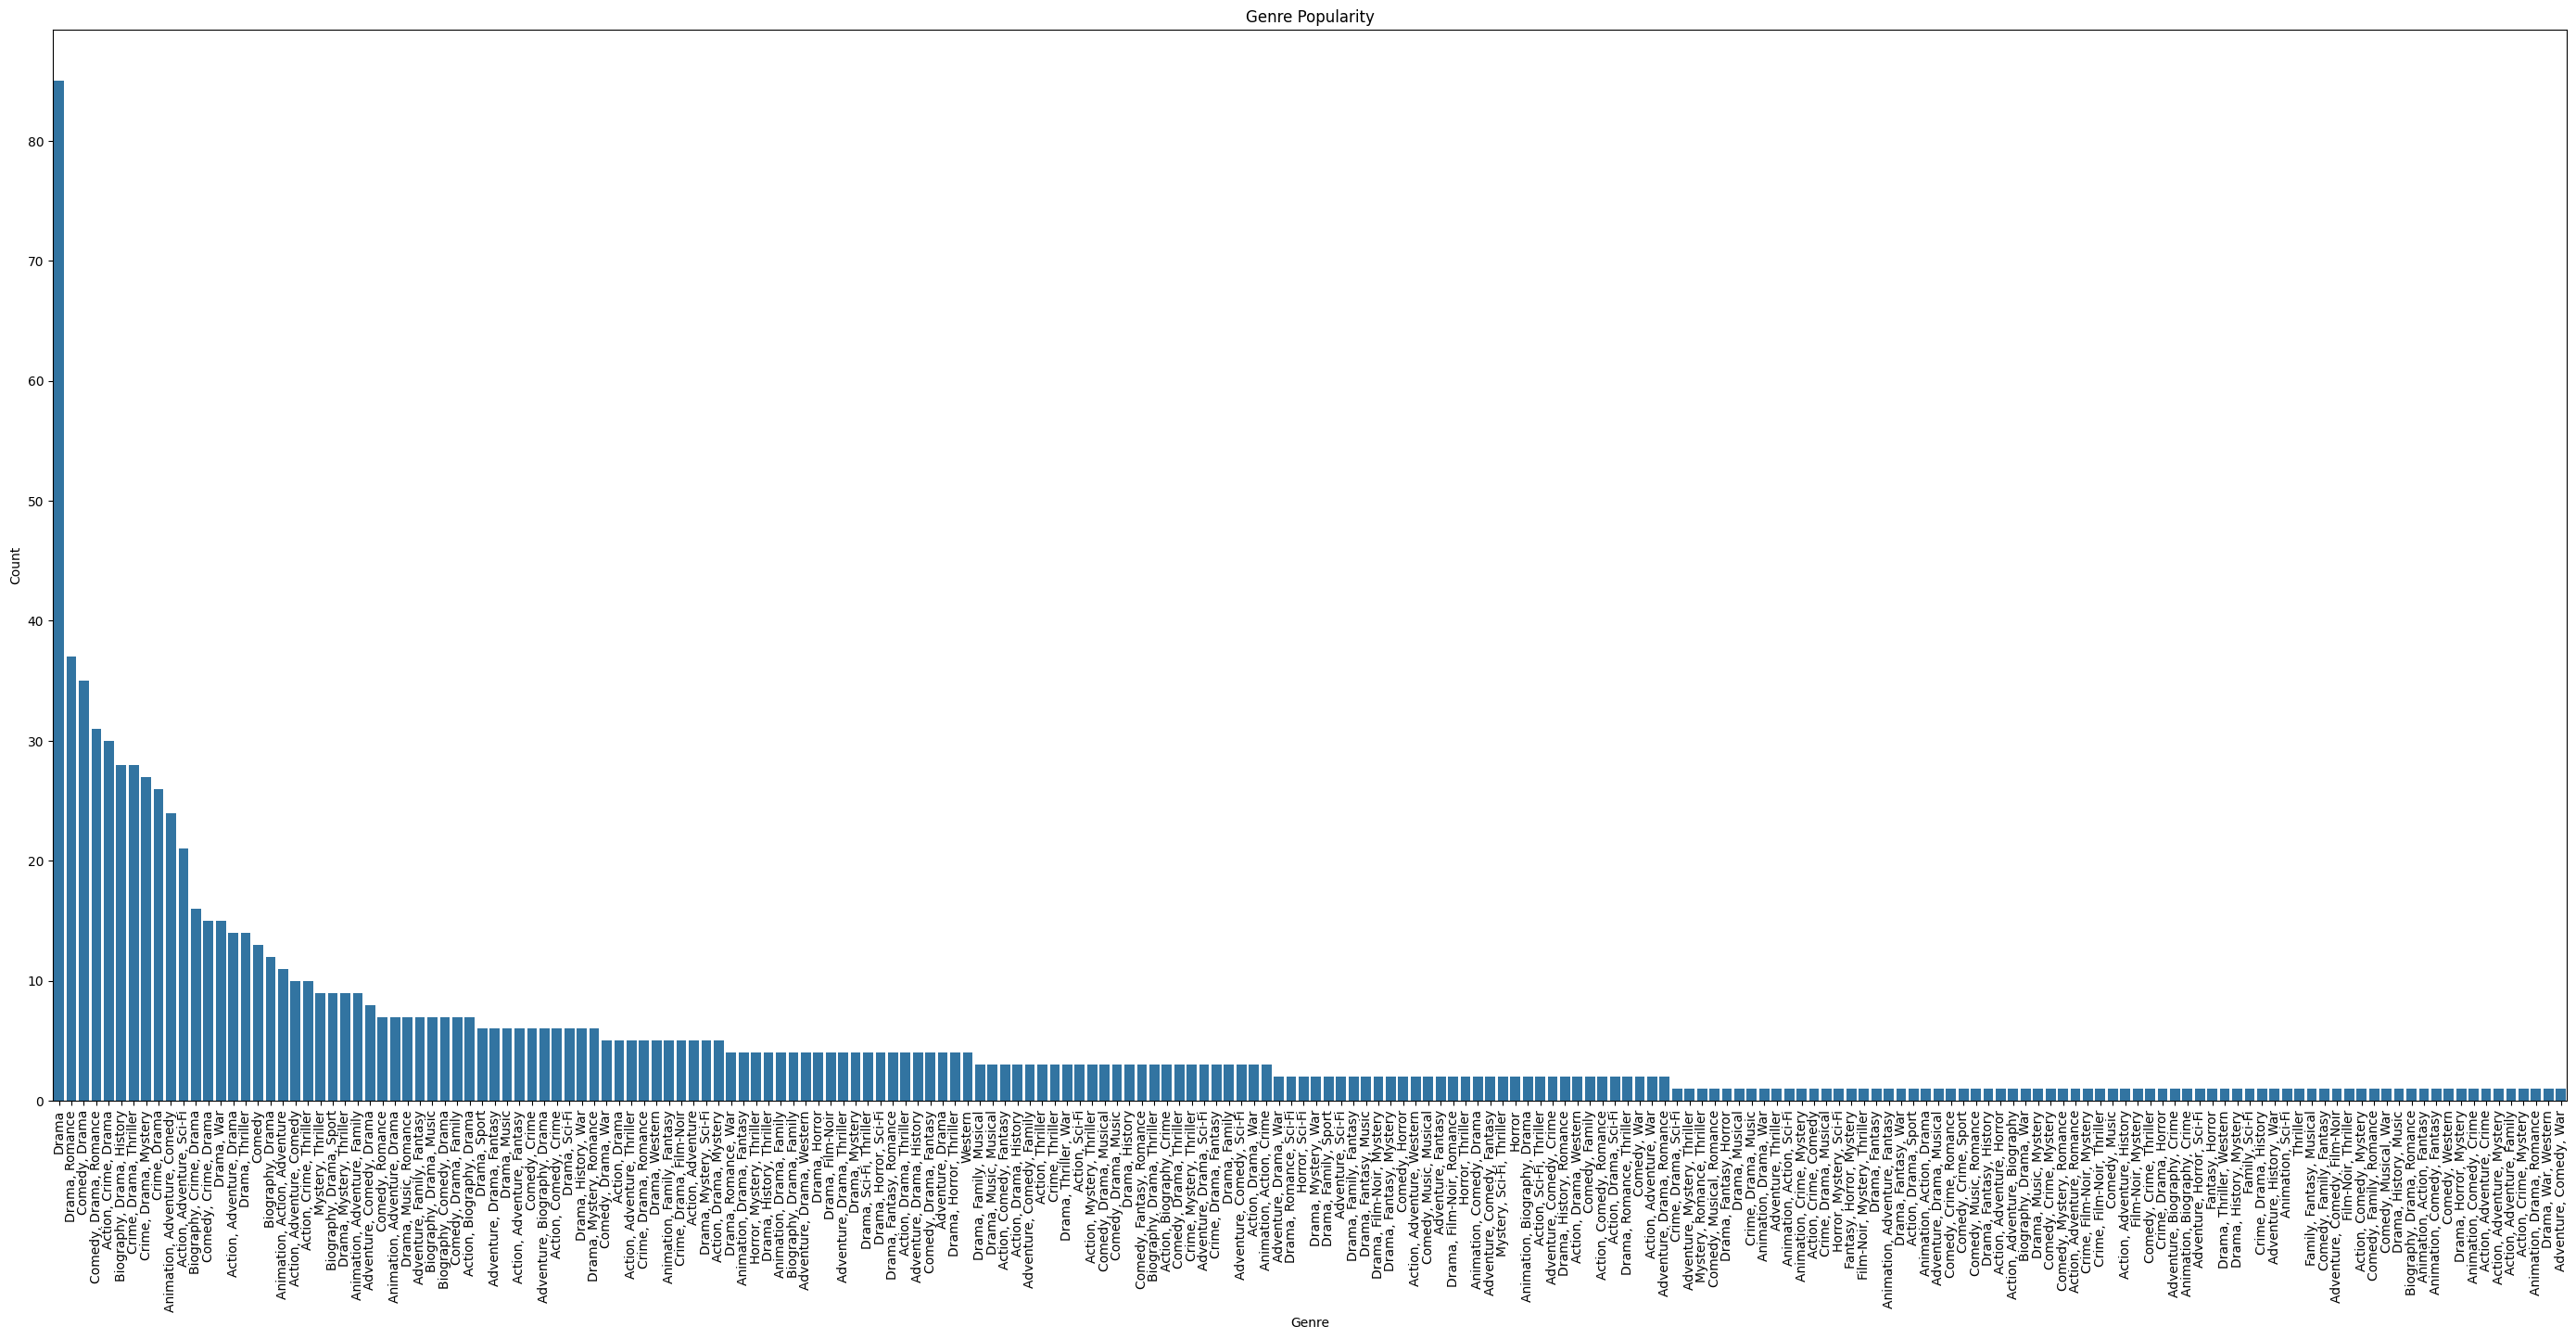

In [9]:
plt.figure(figsize=(35,15))
sns.barplot(x=df['Genre'].value_counts().index, y=df['Genre'].value_counts())
plt.title('Genre Popularity')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

#**Director’s Impact on Ratings:**


Use a Matplotlib scatter plot to examine the relationship between directors and movie ratings

548


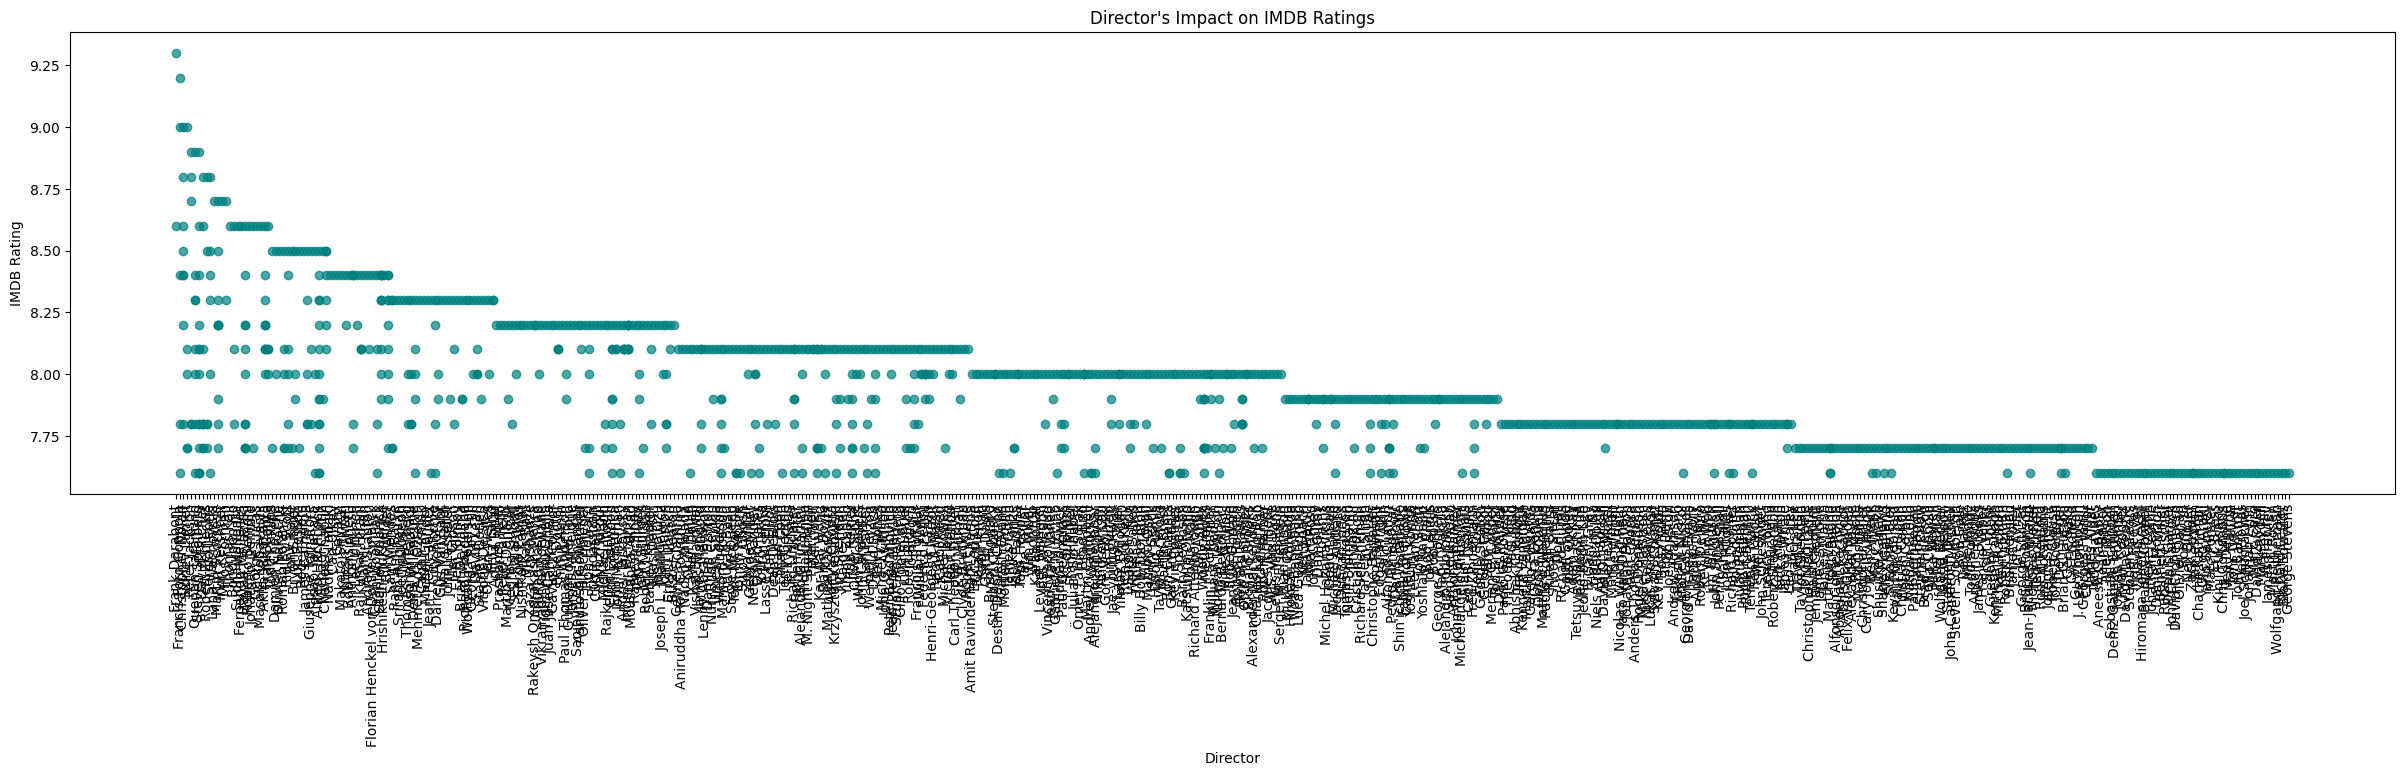

In [10]:
print(len(df['Director'].unique()))

plt.figure(figsize=(30,6))
plt.scatter(df['Director'], df['IMDB_Rating'], alpha=0.7, color='teal')
plt.title("Director's Impact on IMDB Ratings")
plt.xlabel("Director")
plt.ylabel("IMDB Rating")
plt.xticks(rotation=90)
plt.show()


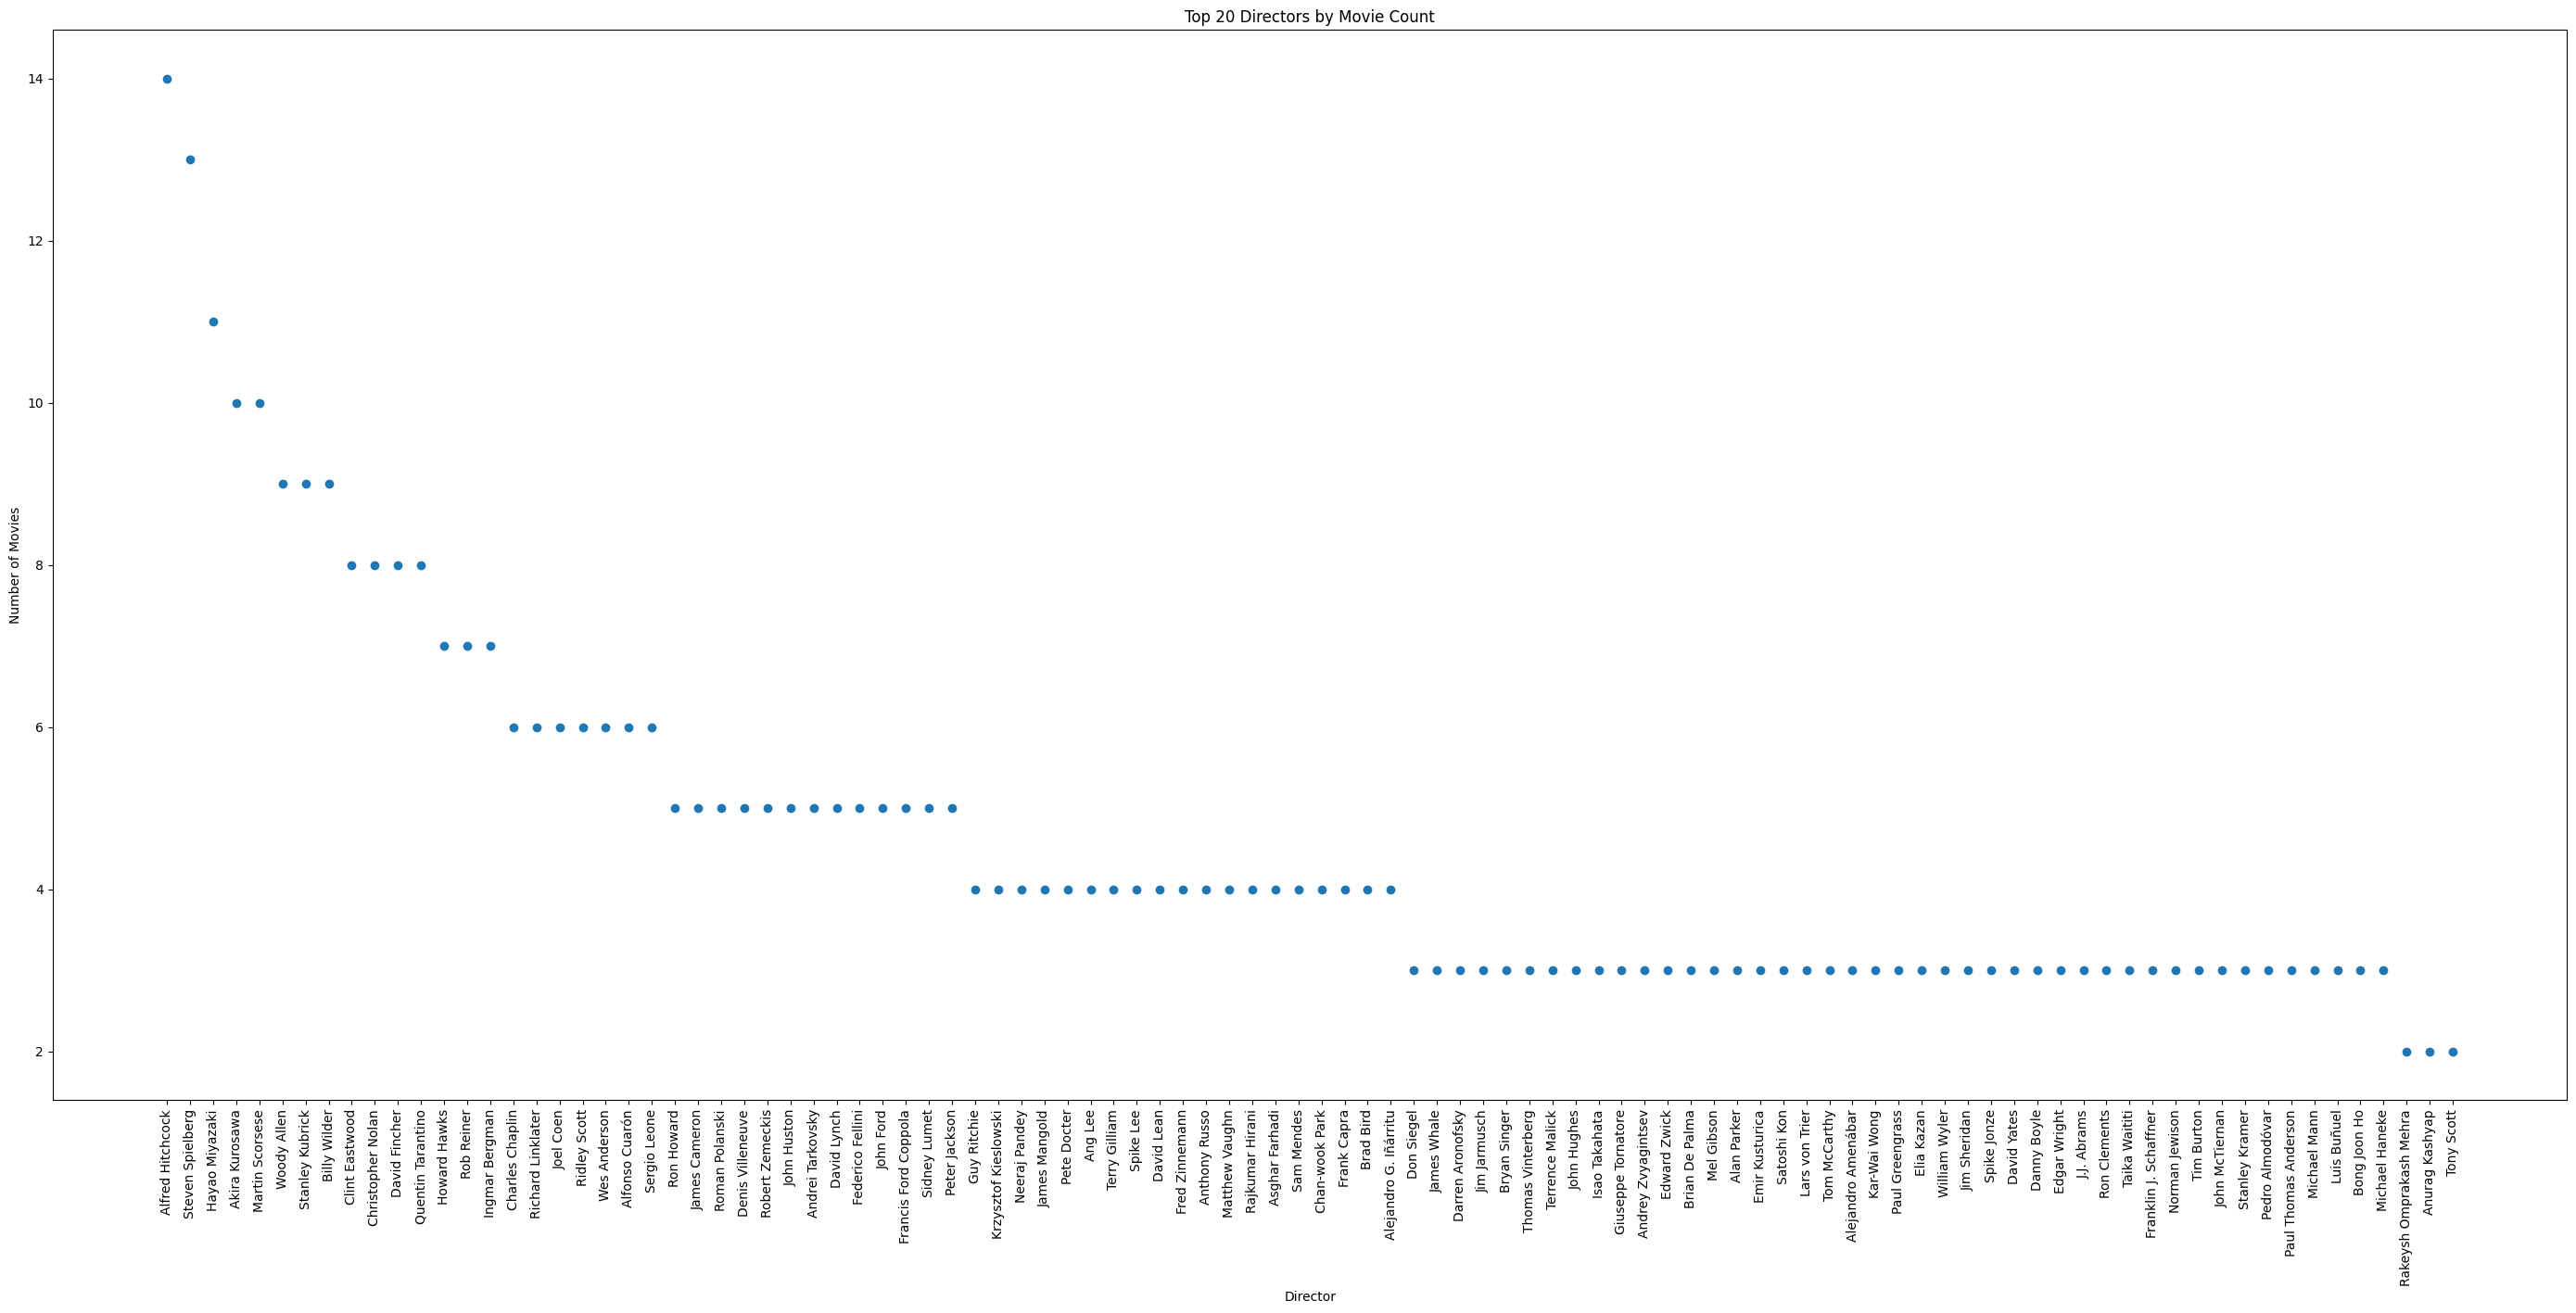

In [20]:
plt.figure(figsize=(35,15))

# Get director counts
director_counts = df['Director'].value_counts()

# Select top 20 directors
top_20_directors = director_counts.head(100)

plt.scatter(top_20_directors.index, top_20_directors.values)
plt.title('Top 20 Directors by Movie Count')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=90)
plt.show()

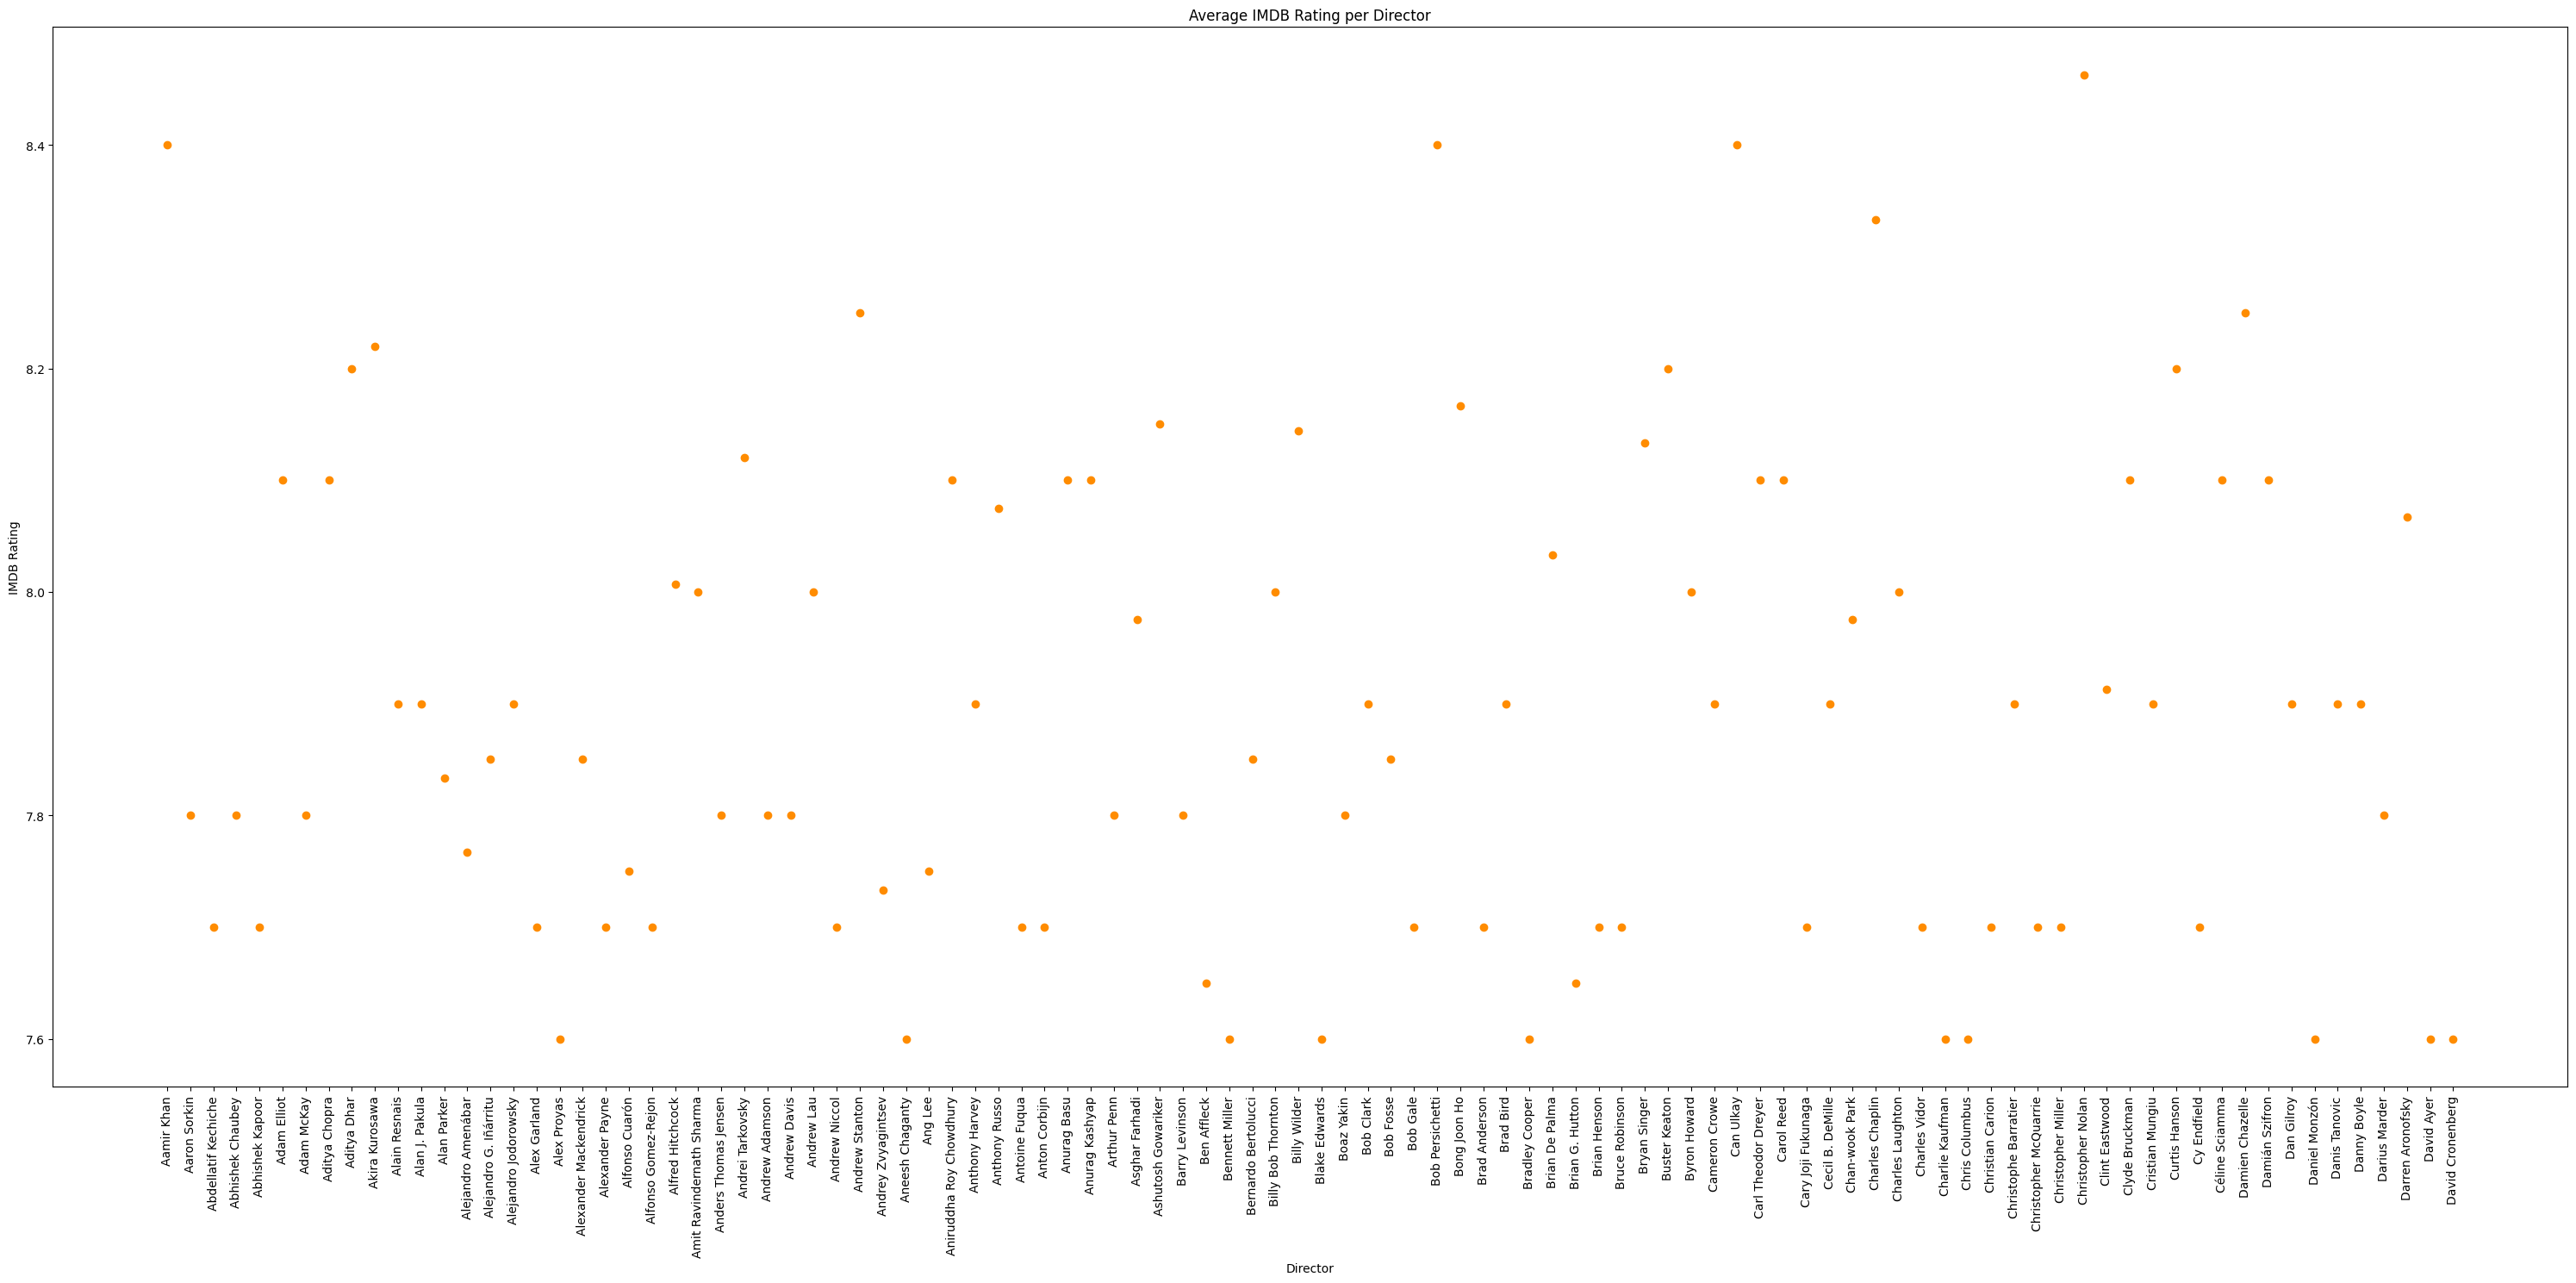

In [16]:
plt.figure(figsize=(30,15))
director_avg = df.groupby('Director')['IMDB_Rating'].mean().reset_index()
#plt.scatter(director_avg['Director'], director_avg['IMDB_Rating'], color='darkorange')
subset = director_avg.head(100)

plt.scatter(subset['Director'], subset['IMDB_Rating'], color='darkorange')
plt.xticks(rotation=90)
plt.title("Average IMDB Rating per Director")
plt.xlabel("Director")
plt.ylabel("IMDB Rating")
plt.tight_layout()
plt.show()



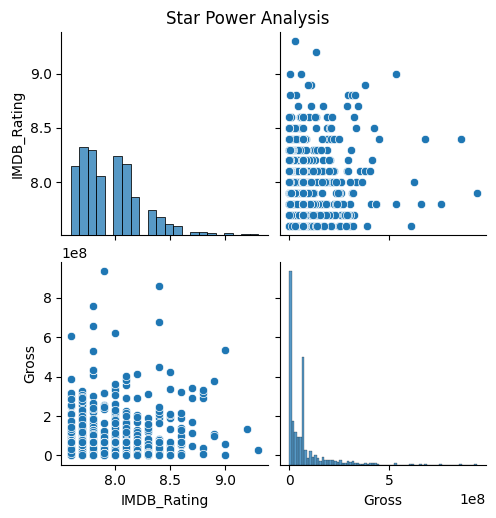

In [21]:
# 2. Star Power Analysis
if 'Star1' in df.columns:
    sns.pairplot(df, vars=['IMDB_Rating', 'Gross'])
    plt.suptitle("Star Power Analysis", y=1.02)
    plt.show()


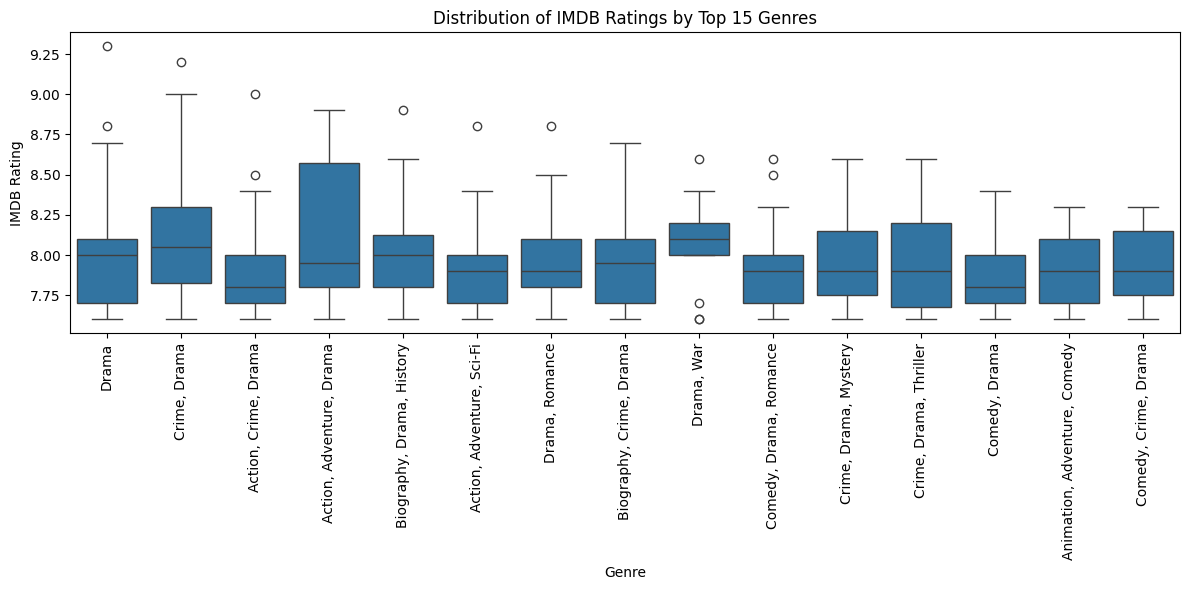

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top N genres (e.g., top 15) for better visualization
top_genres = df['Genre'].value_counts().head(15).index
df_top_genres = df[df['Genre'].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_genres, x='Genre', y='IMDB_Rating')
plt.title("Distribution of IMDB Ratings by Top 15 Genres")
plt.xlabel("Genre")
plt.ylabel("IMDB Rating")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

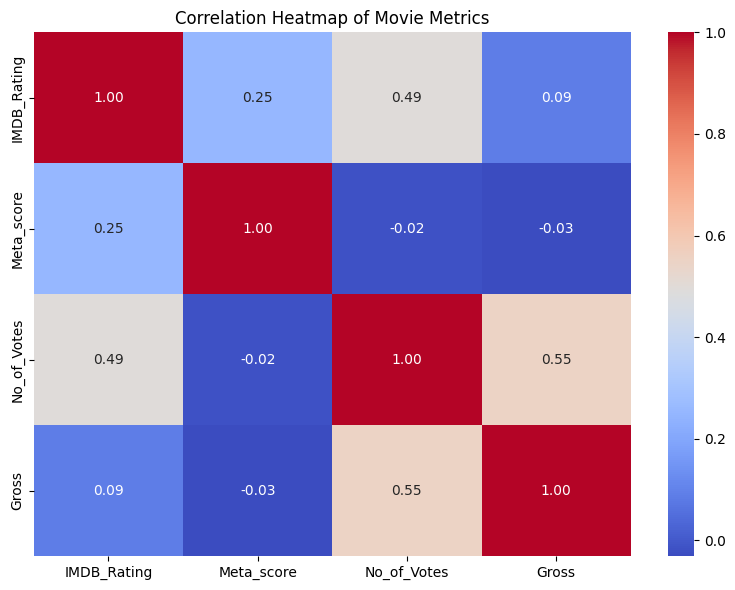

In [26]:
# 4. Correlation Heatmap
numeric_cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross'] # Corrected 'No_of_votes' to 'No_of_Votes'
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Movie Metrics")
plt.tight_layout()
plt.show()